# Análise de Dados - Netflix

### Para esse Business Case, será utilizado uma base de dados disponibilizada pela Netflix através do [Kaggle](https://www.kaggle.com/datasets/shivamb/netflix-shows).

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

## Carregando e Tratando os dados

In [3]:
# mesmo usando o parse a coluna date_added permaneceu como object, provavelmente possue alguns espaços em branco nestes dados...
# a conversão será feita depois

df_netflix = pd.read_csv('dataset/netflix.csv', parse_dates=['date_added'])

In [4]:
df_netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df_netflix['date_added'] = pd.to_datetime(
    df_netflix['date_added'].str.strip(),   # remove possíveis espaços extras
    format='%B %d, %Y',                     # informa explícita mente o formato desejadao: acelera muito
    errors='coerce'                         # transforma erros em NaT ao invés de quebrar
)
print(type(df_netflix['date_added']))

<class 'pandas.core.series.Series'>


In [5]:
df_netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


In [6]:
# Como boa prática....
df_netflix_trat = df_netflix.copy()

In [7]:
df_netflix_trat.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
df_netflix_trat.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [9]:
# alterando o nome das colunas
df_netflix_trat.columns = ['id', 'tipo', 'titulo', 'diretor', 'elenco', 'pais', 'dt_disponibilizacao',
       'ano_lancamento', 'classificacao', 'duracao', 'categorias', 'descricao']

In [10]:
df_netflix_trat.head()

,id,tipo,titulo,diretor,elenco,pais,dt_disponibilizacao,ano_lancamento,classificacao,duracao,categorias,descricao
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Respondendo algumas perguntas

> 1. Quantos registros e quantas colunas existem no dataset?

In [11]:
linhas, colunas = df_netflix_trat.shape
print(f"O dataset possui {linhas} linhas e {colunas} colunas.")

O dataset possui 8807 linhas e 12 colunas.


> 2. Existem colunas com valores ausentes? quais?
Sim: diretor (29.9%), elenco (9.3%), pais (9.4%), dt_disponibilizacao (0.11%), classificacao (0.04%) e duracao (0.03%) .

In [12]:
df_netflix_trat.isna().sum()

id                        0
tipo                      0
titulo                    0
diretor                2634
elenco                  825
pais                    831
dt_disponibilizacao      10
ano_lancamento            0
classificacao             4
duracao                   3
categorias                0
descricao                 0
dtype: int64

In [13]:
# em porcentagem
df_netflix_trat.isna().sum() / linhas * 100

id                      0.000000
tipo                    0.000000
titulo                  0.000000
diretor                29.908028
elenco                  9.367549
pais                    9.435676
dt_disponibilizacao     0.113546
ano_lancamento          0.000000
classificacao           0.045418
duracao                 0.034064
categorias              0.000000
descricao               0.000000
dtype: float64

> 3. Quantas séries (TV Show) e quantos filmes (Movie) estão disponíveis?
Movie: 6131 (70%)
TV Show: 2676 (30%)

In [14]:
df_netflix_trat.head()

,id,tipo,titulo,diretor,elenco,pais,dt_disponibilizacao,ano_lancamento,classificacao,duracao,categorias,descricao
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [15]:
df_netflix_trat['tipo'].value_counts()

tipo
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [16]:
# Em porcentagem
df_netflix_trat['tipo'].value_counts(normalize=True) * 100

tipo
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64

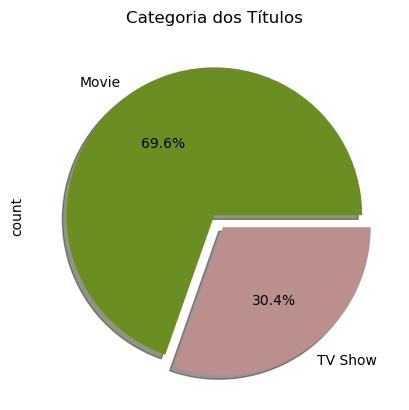

In [18]:
df_netflix_trat['tipo'].value_counts().plot(kind='pie', explode=(0, 0.1), colors=['olivedrab', 'rosybrown'], shadow=True, title='Categoria dos Títulos', autopct='%1.1f%%')
plt.show()

> 4. Quantos registros no dataset estão sem o país especificado? Liste os seus tipos (filme ou série de tv) e quantidades.

In [19]:
df_netflix_sem_pais = df_netflix_trat.loc[df_netflix_trat['pais'].isna()]

In [20]:
df_netflix_sem_pais.shape

(831, 12)

In [21]:
df_netflix_sem_pais['tipo'].value_counts()

tipo
Movie      440
TV Show    391
Name: count, dtype: int64

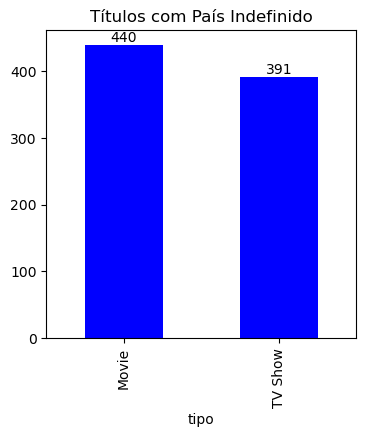

In [42]:
fig, ax = plt.subplots(figsize=(4, 4))
df_netflix_sem_pais['tipo'].value_counts().plot(kind='bar', title="Títulos com País Indefinido", color='blue')
for i, value in enumerate(df_netflix_sem_pais['tipo'].value_counts().values):
    plt.text(i, value + 5, str(value), ha='center')
plt.show()

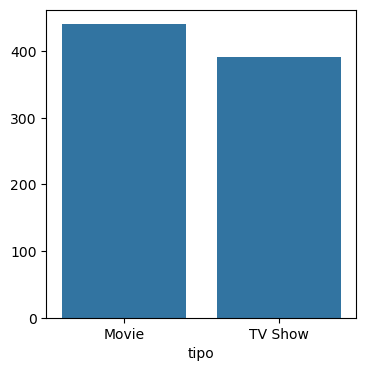

In [43]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(x=df_netflix_sem_pais['tipo'].value_counts().index, y=df_netflix_sem_pais['tipo'].value_counts().values)
plt.show()

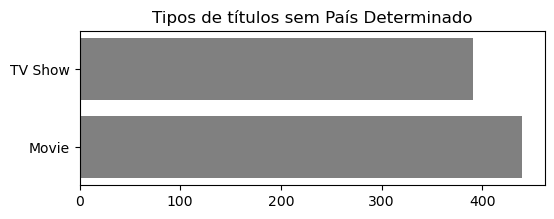

In [36]:
plt.figure(figsize=(6, 2))
plt.barh(y=df_netflix_sem_pais['tipo'].value_counts().index, width=df_netflix_sem_pais['tipo'].value_counts().values, color='grey')
plt.title('Tipos de títulos sem País Determinado')
plt.show()

> 5. Qual a data do primeiro filme disponibilizado e qual o seu título e país?
O primeiro filme foi disponibilizado em 01-01-2008. 
Seu título é: To and From New York.
País de origem: Estados Unidos.

In [45]:
df_netflix_movie = df_netflix_trat.loc[df_netflix_trat['tipo'] == 'Movie']

In [46]:
df_netflix_movie['dt_disponibilizacao'].min()

Timestamp('2008-01-01 00:00:00')

In [47]:
df_netflix_movie[df_netflix_movie['dt_disponibilizacao'] == df_netflix_movie['dt_disponibilizacao'].min()]

,id,tipo,titulo,diretor,elenco,pais,dt_disponibilizacao,ano_lancamento,classificacao,duracao,categorias,descricao
5957,s5958,Movie,To and From New York,Sorin Dan Mihalcescu,"Barbara King, Shaana Diya, John Krisiukenas, Y...",United States,2008-01-01,2006,TV-MA,81 min,"Dramas, Independent Movies, Thrillers","While covering a story in New York City, a Sea..."


> 6. Qual o diretor com maior número de títulos(filme ou série)? Qual o seu país?
Diretor: Rajiv Chilaka - País: Índia (confirmado por pesquisa no Google também)

In [48]:
df_netflix_trat['diretor'].value_counts()

diretor
Rajiv Chilaka              19
Raúl Campos, Jan Suter     18
Suhas Kadav                16
Marcus Raboy               16
Jay Karas                  14
                           ..
James Brown                 1
Ivona Juka                  1
Mu Chu                      1
Chandra Prakash Dwivedi     1
Majid Al Ansari             1
Name: count, Length: 4528, dtype: int64

In [49]:
df_netflix_trat.loc[df_netflix_trat['diretor'] == 'Rajiv Chilaka']

,id,tipo,titulo,diretor,elenco,pais,dt_disponibilizacao,ano_lancamento,classificacao,duracao,categorias,descricao
406,s407,Movie,Chhota Bheem - Neeli Pahaadi,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2013,TV-Y7,64 min,Children & Family Movies,Things get spooky when Bheem and his buddies t...
407,s408,Movie,Chhota Bheem & Ganesh,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2009,TV-Y7,68 min,Children & Family Movies,Bheem and Lord Ganesha join forces to save Dho...
408,s409,Movie,Chhota Bheem & Krishna: Mayanagari,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2011,TV-Y7,67 min,Children & Family Movies,Young lord Krishna has fallen for demoness Maa...
409,s410,Movie,Chhota Bheem & Krishna: Pataliputra- City of t...,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2010,TV-Y7,66 min,Children & Family Movies,Krishna needs Bheem’s help: The ruined city of...
410,s411,Movie,Chhota Bheem And The Broken Amulet,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",India,2021-07-22,2013,TV-Y7,64 min,Children & Family Movies,When a stranger tries to steal an amulet from ...
411,s412,Movie,Chhota Bheem And The Crown of Valhalla,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2013,TV-Y7,64 min,Children & Family Movies,To save the kingdom of Valhalla from invasion ...
412,s413,Movie,Chhota Bheem and the Incan Adventure,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2013,TV-Y7,65 min,Children & Family Movies,"When Dholakpur’s princess is kidnapped, Bheem ..."
413,s414,Movie,Chhota Bheem and The ShiNobi Secret,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2013,TV-Y7,64 min,Children & Family Movies,After learning of a samurai village under thre...
414,s415,Movie,Chhota Bheem Aur Hanuman,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2012,TV-Y7,68 min,Children & Family Movies,When two evil entities kidnap a princess in a ...
415,s416,Movie,Chhota Bheem aur Krishna,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",India,2021-07-22,2009,TV-Y7,68 min,Children & Family Movies,"Centuries after the end of a conqueror's rule,..."


In [ ]:
df_netflix_trat.query("diretor == 'Rajiv Chilaka'").head()

,id,tipo,titulo,diretor,elenco,pais,dt_disponibilizacao,ano_lancamento,classificacao,duracao,categorias,descricao
406,s407,Movie,Chhota Bheem - Neeli Pahaadi,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2013,TV-Y7,64 min,Children & Family Movies,Things get spooky when Bheem and his buddies t...
407,s408,Movie,Chhota Bheem & Ganesh,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2009,TV-Y7,68 min,Children & Family Movies,Bheem and Lord Ganesha join forces to save Dho...
408,s409,Movie,Chhota Bheem & Krishna: Mayanagari,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2011,TV-Y7,67 min,Children & Family Movies,Young lord Krishna has fallen for demoness Maa...
409,s410,Movie,Chhota Bheem & Krishna: Pataliputra- City of t...,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2010,TV-Y7,66 min,Children & Family Movies,Krishna needs Bheem’s help: The ruined city of...
410,s411,Movie,Chhota Bheem And The Broken Amulet,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",India,2021-07-22,2013,TV-Y7,64 min,Children & Family Movies,When a stranger tries to steal an amulet from ...
411,s412,Movie,Chhota Bheem And The Crown of Valhalla,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2013,TV-Y7,64 min,Children & Family Movies,To save the kingdom of Valhalla from invasion ...
412,s413,Movie,Chhota Bheem and the Incan Adventure,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2013,TV-Y7,65 min,Children & Family Movies,"When Dholakpur’s princess is kidnapped, Bheem ..."
413,s414,Movie,Chhota Bheem and The ShiNobi Secret,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2013,TV-Y7,64 min,Children & Family Movies,After learning of a samurai village under thre...
414,s415,Movie,Chhota Bheem Aur Hanuman,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",NaN,2021-07-22,2012,TV-Y7,68 min,Children & Family Movies,When two evil entities kidnap a princess in a ...
415,s416,Movie,Chhota Bheem aur Krishna,Rajiv Chilaka,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",India,2021-07-22,2009,TV-Y7,68 min,Children & Family Movies,"Centuries after the end of a conqueror's rule,..."
